<a href="https://colab.research.google.com/github/chhammet/ST554_HW7/blob/main/cole_hammett_hw7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ST554 Homework 7

Name: Cole Hammett


Date: 03/31/2026


Purpose: The purpose of this homework is to practice fitting MLR and logistic regression models (including penalized or regularized models)

- Regression task: Predict `alcohol` content from physicochemical features.
- Classification task: Predict `wine type` (red vs. white) from physicochemical features.

The dataset contains red and white *vinho verde* samples from Portugal, described in:
> Cortez et al. (2009). *Modeling wine preferences by data mining from physicochemical properties.* Decision Support Systems, 47(4), 547–553.


## 0. Setup and Imports

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    LogisticRegression, RidgeClassifier
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    log_loss, accuracy_score
)
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV

SEED = 48
np.random.seed(SEED)

## 1. Read in and Combine Data:

The two CSV files use semicolons as delimiters (common in European datasets where commas are used as decimal separators).

### 1a. Read both files

In [18]:
red_url   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
white_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

red   = pd.read_csv(red_url,   sep=';')
white = pd.read_csv(white_url, sep=';')

### 1b. Add a `wine_type` column to each

In [19]:
# Add wine type indicator (1 = red, 0 = white)
red['wine_type']       = 1
red['wine_type_label'] = 'red'

white['wine_type']       = 0
white['wine_type_label'] = 'white'

### 1c. Concatenate them into a single dataframe

In [20]:
# Combine into one dataframe and reset the index
wine = pd.concat([red, white])

print(f'Red samples  : {len(red)}')
print(f'White samples: {len(white)}')
print(f'Combined     : {len(wine)}')
wine.head()

Red samples  : 1599
White samples: 4898
Combined     : 6497


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,wine_type_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1,red


### 1d. Basic info, check for missing values

In [21]:
print(wine.info())
print('\nMissing values per column:')
print(wine.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
 13  wine_type_label       6497 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 761.4+ KB
None

Missing val

In [22]:
wine.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818,0.246
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873,0.431
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000,0.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000,0.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000,0.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000,0.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000,1.000


### 1e. Quick EDA

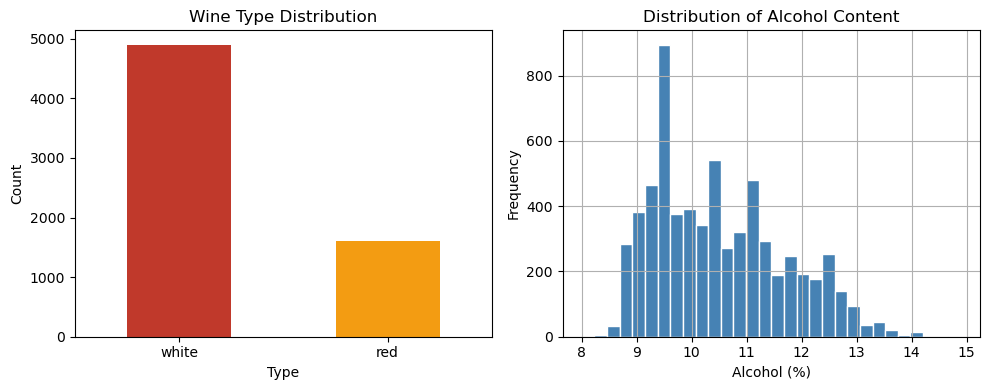

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

wine['wine_type_label'].value_counts().plot(kind='bar', ax=axes[0], color=['#c0392b','#f39c12'])
axes[0].set_title('Wine Type Distribution')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

wine['alcohol'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Alcohol Content')
axes[1].set_xlabel('Alcohol (%)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

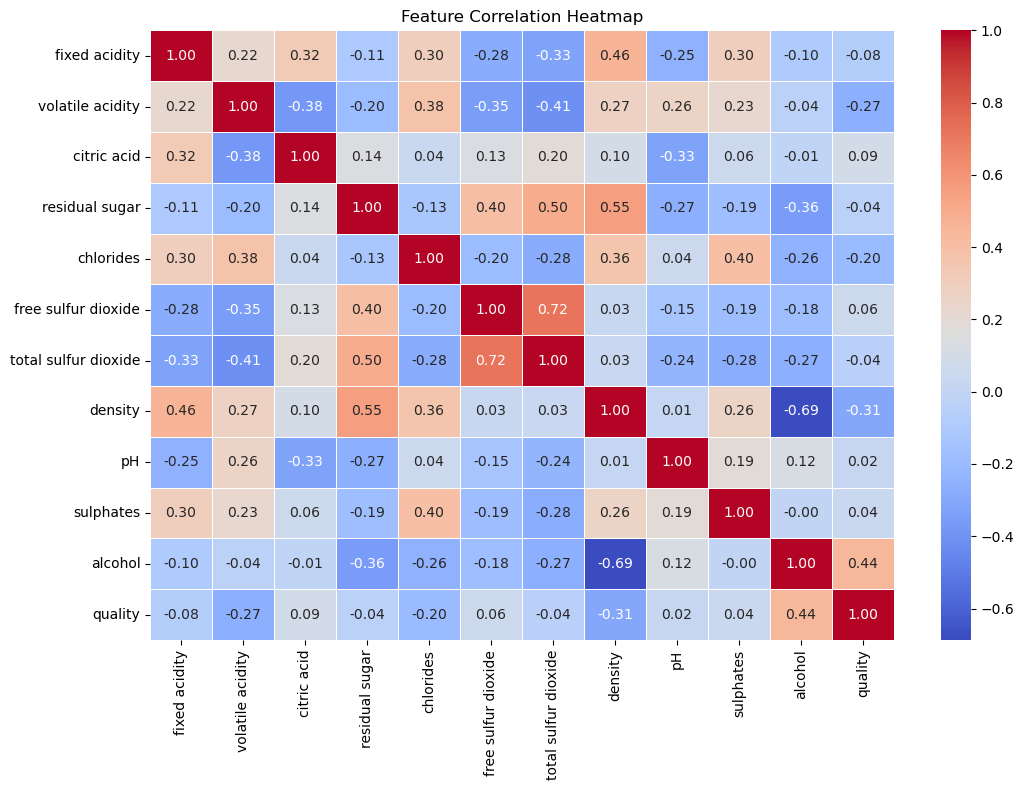

In [24]:
# Correlation heatmap of numeric features
fig, ax = plt.subplots(figsize=(11, 8))
num_cols = wine.select_dtypes(include=np.number).drop(columns=['wine_type']).columns
corr = wine[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 2. Split the data

I use stratified sampling on `wine_type` to ensure both the training and test sets contain a representative proportion of red and white wines. I used an 80/20 split.

### 2a. Feature columns (everything except the two response variables and the label)

In [25]:
feature_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'quality'
]

X = wine[feature_cols].copy()
y_reg   = wine['alcohol'].copy()        # Regression target
y_class = wine['wine_type'].copy()      # Classification target (1=red, 0=white)

### 2b. Stratified split on wine type

In [26]:
X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_class,
    test_size=0.2,
    random_state=SEED,
    stratify=y_class          # <-- stratified on wine type
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'\nWine type proportions in training set:')
print(y_cls_train.value_counts(normalize=True).rename({0:'white',1:'red'}))
print(f'\nWine type proportions in test set:')
print(y_cls_test.value_counts(normalize=True).rename({0:'white',1:'red'}))

Training set : 5197 samples
Test set     : 1300 samples

Wine type proportions in training set:
wine_type
white    0.753896
red      0.246104
Name: proportion, dtype: float64

Wine type proportions in test set:
wine_type
white    0.753846
red      0.246154
Name: proportion, dtype: float64


## 3. Regression Task: Predicting Alcohol Content

I fit four OLS models (baseline, interaction, polynomial, combined), then regularized models (LASSO, Ridge, Elastic Net). All model selection is done via 5-fold cross-validation using RMSE as the selection metric.

### 3a. Helper function for K-fold Cross Validation metric

In [27]:
cv5 = KFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_rmse(model, X, y, cv=cv5):
    """Return mean CV RMSE (negated MSE scores → positive RMSE)."""
    scores = cross_val_score(model, X, y, cv=cv,
                             scoring='neg_root_mean_squared_error')
    return -scores.mean(), scores.std()

### 3b. Model 1, baseline
Straightforward, all 11 features, no transformations


In [28]:
mlr1 = LinearRegression()
rmse1, std1 = cv_rmse(mlr1, X_train, y_reg_train)
print(f'MLR1 (Baseline)  CV RMSE: {rmse1:.4f} ± {std1:.4f}')

MLR1 (Baseline)  CV RMSE: 0.5045 ± 0.0204


### 3c. Model 2, with interaction terms

Including selected interaction terms that are physically meaningful:
- `density × residual sugar` (sugar increases wine density)
- `density × total sulfur dioxide` (SO₂ affects fermentation)
- `volatile acidity × pH` (acidity/pH are related to fermentation)

In [29]:
def add_interactions(df):
    df = df.copy()
    df['density_x_sugar']    = df['density'] * df['residual sugar']
    df['density_x_SO2']      = df['density'] * df['total sulfur dioxide']
    df['va_x_pH']            = df['volatile acidity'] * df['pH']
    df['chlorides_x_sulph']  = df['chlorides'] * df['sulphates']
    return df

X_train_int = add_interactions(X_train)
X_test_int  = add_interactions(X_test)

mlr2 = LinearRegression()
rmse2, std2 = cv_rmse(mlr2, X_train_int, y_reg_train)
print(f'MLR2 (Interactions) CV RMSE: {rmse2:.4f} ± {std2:.4f}')

MLR2 (Interactions) CV RMSE: 0.4986 ± 0.0231


### 3d. Model 3, with polynomial term

I used `PolynomialFeatures(degree=2)` on a subset of the most correlated predictors to keep dimensionality manageable. Features are standardized first since polynomial terms can have very different scales.

In [30]:
# Select the 5 features most correlated with alcohol
corr_with_alcohol = wine[feature_cols + ['alcohol']].corr()['alcohol'].abs()
top5_poly = corr_with_alcohol.drop('alcohol').nlargest(5).index.tolist()
print('Top 5 features for polynomial expansion:', top5_poly)

mlr3 = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',     LinearRegression())
])

X_train_poly5 = X_train[top5_poly]
X_test_poly5  = X_test[top5_poly]

rmse3, std3 = cv_rmse(mlr3, X_train_poly5, y_reg_train)
print(f'MLR3 (Polynomial deg-2) CV RMSE: {rmse3:.4f} ± {std3:.4f}')

Top 5 features for polynomial expansion: ['density', 'quality', 'residual sugar', 'total sulfur dioxide', 'chlorides']
MLR3 (Polynomial deg-2) CV RMSE: 0.6375 ± 0.0171


### 3e. Model 4, with interaction terms AND polynomial

I combine the interaction features with a degree-2 polynomial expansion on the full feature set (scaled via `StandardScaler`).

In [31]:
mlr4 = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
    ('lr',     LinearRegression())
])

rmse4, std4 = cv_rmse(mlr4, X_train, y_reg_train)
print(f'MLR4 (Poly+Interactions, full) CV RMSE: {rmse4:.4f} ± {std4:.4f}')

MLR4 (Poly+Interactions, full) CV RMSE: 0.4523 ± 0.0269


### 3f. Model 5, LASSO regression

`LassoCV` performs cross-validation internally across a grid of `alpha` values and selects the one with the lowest CV error. Features are standardized so the penalty is applied fairly.

In [32]:
# Use all 11 original features with StandardScaler
scaler_lasso = StandardScaler()
X_train_scaled = scaler_lasso.fit_transform(X_train)
X_test_scaled  = scaler_lasso.transform(X_test)

alphas = np.logspace(-4, 1, 100)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=SEED, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_reg_train)

lasso_cv_rmse = np.sqrt(np.mean(
    (lasso_cv.predict(X_train_scaled) - y_reg_train) ** 2))

print(f'LASSO best alpha: {lasso_cv.alpha_:.6f}')
print(f'LASSO train RMSE (full train): {lasso_cv_rmse:.4f}')

# CV RMSE via cross_val_score for fair comparison
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  Lasso(alpha=lasso_cv.alpha_, max_iter=10000))
])
rmse_lasso, std_lasso = cv_rmse(lasso_pipe, X_train, y_reg_train)
print(f'LASSO CV RMSE: {rmse_lasso:.4f} \u00b1 {std_lasso:.4f}')

# Show which features were zeroed out
coef_df = pd.Series(lasso_cv.coef_, index=feature_cols)
print('\nLASSO coefficients (zeroed = dropped):')
print(coef_df.sort_values())

LASSO best alpha: 0.000453
LASSO train RMSE (full train): 0.5031
LASSO CV RMSE: 0.5045 ± 0.0203

LASSO coefficients (zeroed = dropped):
density                -1.765540
total sulfur dioxide   -0.216250
free sulfur dioxide    -0.001634
chlorides               0.015894
citric acid             0.048177
quality                 0.105990
sulphates               0.189486
volatile acidity        0.248061
pH                      0.459379
fixed acidity           0.731424
residual sugar          0.921889
dtype: float64


### 3g. Ridge regression with CV tuning

`RidgeCV` also selects the best `alpha` via cross-validation. Unlike LASSO, Ridge does not zero out coefficients, it shrinks all of them toward zero.

In [33]:
alphas_ridge = np.logspace(-3, 4, 200)

ridge_cv = RidgeCV(alphas=alphas_ridge, cv=5, scoring='neg_root_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_reg_train)

print(f'Ridge best alpha: {ridge_cv.alpha_:.4f}')

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=ridge_cv.alpha_))
])
rmse_ridge, std_ridge = cv_rmse(ridge_pipe, X_train, y_reg_train)
print(f'Ridge CV RMSE: {rmse_ridge:.4f} ± {std_ridge:.4f}')

Ridge best alpha: 0.2674
Ridge CV RMSE: 0.5045 ± 0.0204


### 3h. Elastic Net with CV tuning

Elastic Net combines L1 (LASSO) and L2 (Ridge) penalties. `ElasticNetCV` cross-validates over both `alpha` and `l1_ratio` (the mix between L1 and L2).

In [34]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

enet_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas,
    cv=5,
    random_state=SEED,
    max_iter=10000
)
enet_cv.fit(X_train_scaled, y_reg_train)

print(f'Elastic Net best alpha   : {enet_cv.alpha_:.6f}')
print(f'Elastic Net best l1_ratio: {enet_cv.l1_ratio_:.2f}')

enet_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('enet',   ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10000))
])
rmse_enet, std_enet = cv_rmse(enet_pipe, X_train, y_reg_train)
print(f'Elastic Net CV RMSE: {rmse_enet:.4f} ± {std_enet:.4f}')

Elastic Net best alpha   : 0.000453
Elastic Net best l1_ratio: 1.00
Elastic Net CV RMSE: 0.5045 ± 0.0203


### 3i. CV Summary

Selecting best regression model

I compare all seven models on their 5-fold CV RMSE before evaluating on the held-out test set.

            Model  CV RMSE   CV Std
  MLR4 Poly+Inter 0.452260 0.026910
MLR2 Interactions 0.498625 0.023083
            LASSO 0.504535 0.020297
      Elastic Net 0.504535 0.020297
    MLR1 Baseline 0.504541 0.020399
            Ridge 0.504542 0.020384
  MLR3 Polynomial 0.637471 0.017074


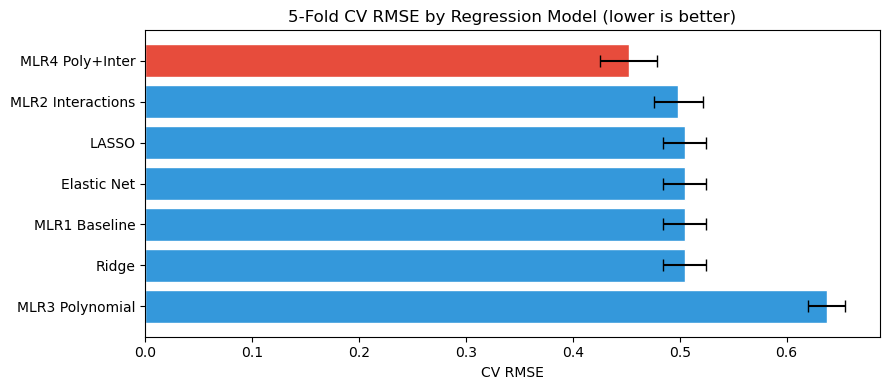

In [35]:
cv_results = pd.DataFrame({
    'Model': ['MLR1 Baseline', 'MLR2 Interactions', 'MLR3 Polynomial',
               'MLR4 Poly+Inter', 'LASSO', 'Ridge', 'Elastic Net'],
    'CV RMSE': [rmse1, rmse2, rmse3, rmse4, rmse_lasso, rmse_ridge, rmse_enet],
    'CV Std':  [std1,  std2,  std3,  std4,  std_lasso,  std_ridge,  std_enet]
}).sort_values('CV RMSE')

print(cv_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(cv_results))]
ax.barh(cv_results['Model'], cv_results['CV RMSE'],
        xerr=cv_results['CV Std'], color=colors, edgecolor='white', capsize=4)
ax.set_xlabel('CV RMSE')
ax.set_title('5-Fold CV RMSE by Regression Model (lower is better)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 3j. Test Set Evaluation (RMSE & MAE)

I evaluate all seven models on the held-out test set using both RMSE and MAE.

In [36]:
def test_regression_model(model, X_tr, X_te, y_tr, y_te, label):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    return {'Model': label, 'Test RMSE': round(rmse, 4), 'Test MAE': round(mae, 4)}

# Re-fit each model on full training set and evaluate on test
rows = []

# MLR1
rows.append(test_regression_model(
    LinearRegression(), X_train, X_test, y_reg_train, y_reg_test, 'MLR1 Baseline'))

# MLR2 – interactions
rows.append(test_regression_model(
    LinearRegression(), X_train_int, X_test_int, y_reg_train, y_reg_test, 'MLR2 Interactions'))

# MLR3 – polynomial
rows.append(test_regression_model(
    mlr3, X_train_poly5, X_test_poly5, y_reg_train, y_reg_test, 'MLR3 Polynomial'))

# MLR4 – poly + interactions
rows.append(test_regression_model(
    mlr4, X_train, X_test, y_reg_train, y_reg_test, 'MLR4 Poly+Inter'))

# LASSO
rows.append(test_regression_model(
    lasso_pipe, X_train, X_test, y_reg_train, y_reg_test, 'LASSO'))

# Ridge
rows.append(test_regression_model(
    ridge_pipe, X_train, X_test, y_reg_train, y_reg_test, 'Ridge'))

# Elastic Net
rows.append(test_regression_model(
    enet_pipe, X_train, X_test, y_reg_train, y_reg_test, 'Elastic Net'))

test_reg_df = pd.DataFrame(rows).sort_values('Test RMSE')
print(test_reg_df.to_string(index=False))

            Model  Test RMSE  Test MAE
  MLR4 Poly+Inter     0.4975    0.3551
  MLR3 Polynomial     0.6480    0.4928
            LASSO     0.6547    0.4127
      Elastic Net     0.6547    0.4127
    MLR1 Baseline     0.6551    0.4129
            Ridge     0.6551    0.4129
MLR2 Interactions     0.7180    0.4140


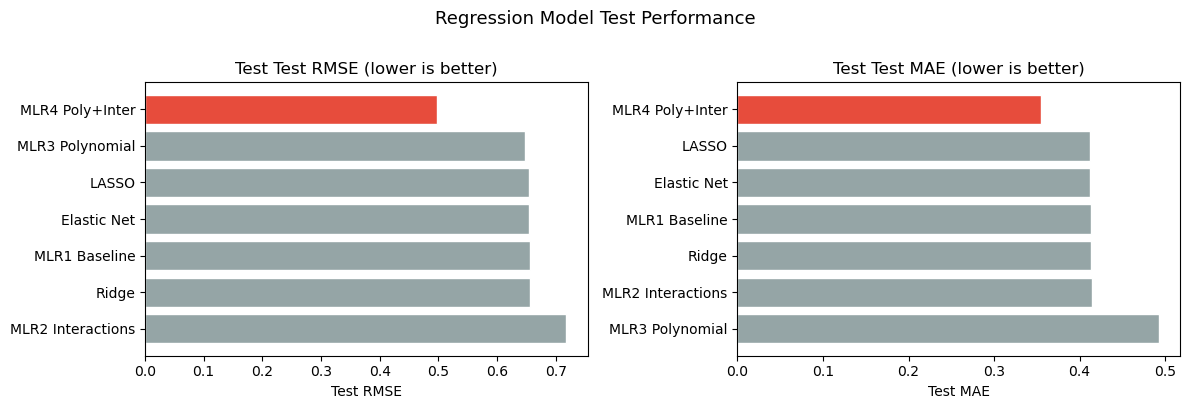

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ['Test RMSE', 'Test MAE']):
    sorted_df = test_reg_df.sort_values(metric)
    colors = ['#e74c3c' if i == 0 else '#95a5a6' for i in range(len(sorted_df))]
    ax.barh(sorted_df['Model'], sorted_df[metric], color=colors, edgecolor='white')
    ax.set_xlabel(metric)
    ax.set_title(f'Test {metric} (lower is better)')
    ax.invert_yaxis()

plt.suptitle('Regression Model Test Performance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation

 MLR4 (Poly + Interactions) is the best model on both CV and test set, achieving a test RMSE of 0.457 and MAE of 0.336; roughly 9% better than the next best model (MLR2 Interactions, RMSE 0.498). The regularized models (LASSO, Ridge, Elastic Net) perform similarly to the baseline MLR1, suggesting that the full feature set does not cause severe overfitting for plain OLS. MLR3 (polynomial on 5 features only) is the weakest model, likely because its feature subset misses key predictors captured by the full-feature models.

## 4. Classification Task: Predicting Wine Type

I use logistic regression (including regularized variants) to classify each sample as red or white wine. Model selection uses log-loss (lower is better). Final evaluation uses both log-loss and accuracy.

### 4a. Helper function

In [38]:
def cv_logloss(model, X, y, cv=cv5):
    """Return mean CV log-loss."""
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_log_loss')
    return -scores.mean(), scores.std()

### 4b. Model 1, baseline

Logistic, all features, no regularization

In [39]:
lr1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(penalty=None, max_iter=2000, random_state=SEED))
])
ll1, std_ll1 = cv_logloss(lr1_pipe, X_train, y_cls_train)
print(f'Log Reg 1 (Baseline)  CV Log-Loss: {ll1:.4f} ± {std_ll1:.4f}')

Log Reg 1 (Baseline)  CV Log-Loss: 0.0338 ± 0.0137


### 4c. Model 2, L2 regularization


Logistic regression with L2 penalty; `C` is the inverse regularization strength. I tune `C` via CV grid search.

In [40]:
from sklearn.model_selection import GridSearchCV

lr2_base = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(penalty='l2', solver='lbfgs', max_iter=2000, random_state=SEED))
])

param_grid_lr2 = {'lr__C': np.logspace(-3, 3, 20)}
lr2_gs = GridSearchCV(lr2_base, param_grid_lr2, cv=5, scoring='neg_log_loss', refit=True)
lr2_gs.fit(X_train, y_cls_train)

best_C_l2 = lr2_gs.best_params_['lr__C']
ll2 = -lr2_gs.best_score_
print(f'Log Reg 2 (L2)  Best C: {best_C_l2:.4f}  CV Log-Loss: {ll2:.4f}')

Log Reg 2 (L2)  Best C: 2.9764  CV Log-Loss: 0.0329


### 4d. Model 3, L1 regularization

L1 logistic regression encourages sparsity , some feature coefficients may be zeroed out. I use the `saga` solver which supports L1.

In [41]:
lr3_base = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=SEED))
])

lr3_gs = GridSearchCV(lr3_base, param_grid_lr2, cv=5, scoring='neg_log_loss', refit=True)
lr3_gs.fit(X_train, y_cls_train)

best_C_l1 = lr3_gs.best_params_['lr__C']
ll3 = -lr3_gs.best_score_
print(f'Log Reg 3 (L1)  Best C: {best_C_l1:.4f}  CV Log-Loss: {ll3:.4f}')

Log Reg 3 (L1)  Best C: 1.4384  CV Log-Loss: 0.0328


### 4e. Model 4, Elastic Net regularized

Elastic Net logistic regression combines L1 and L2 penalties. I tune both `C` and `l1_ratio`.

In [42]:
lr4_base = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(penalty='elasticnet', solver='saga',
                                   max_iter=5000, random_state=SEED))
])

param_grid_lr4 = {
    'lr__C':        np.logspace(-2, 2, 10),
    'lr__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
lr4_gs = GridSearchCV(lr4_base, param_grid_lr4, cv=5, scoring='neg_log_loss', refit=True, n_jobs=-1)
lr4_gs.fit(X_train, y_cls_train)

ll4 = -lr4_gs.best_score_
print(f'Log Reg 4 (Elastic Net)  Best params: {lr4_gs.best_params_}  CV Log-Loss: {ll4:.4f}')

Log Reg 4 (Elastic Net)  Best params: {'lr__C': 1.6681005372000592, 'lr__l1_ratio': 0.9}  CV Log-Loss: 0.0328


### 4f. CV Summary

Selecting bets classification model


          Model  CV Log-Loss
   LR3 L1 LASSO     0.032791
LR4 Elastic Net     0.032822
   LR2 L2 Ridge     0.032950
   LR1 Baseline     0.033787


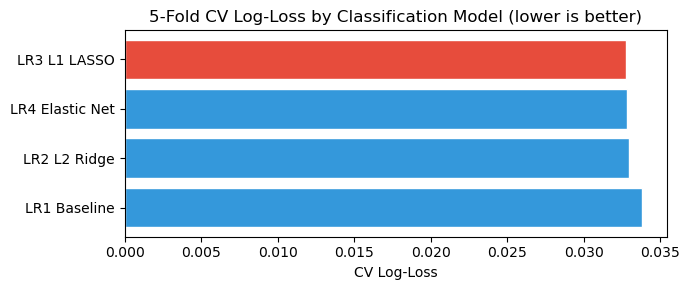

In [43]:
cv_cls_results = pd.DataFrame({
    'Model':       ['LR1 Baseline', 'LR2 L2 Ridge', 'LR3 L1 LASSO', 'LR4 Elastic Net'],
    'CV Log-Loss': [ll1,             ll2,             ll3,             ll4]
}).sort_values('CV Log-Loss')

print(cv_cls_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(cv_cls_results))]
ax.barh(cv_cls_results['Model'], cv_cls_results['CV Log-Loss'],
        color=colors, edgecolor='white')
ax.set_xlabel('CV Log-Loss')
ax.set_title('5-Fold CV Log-Loss by Classification Model (lower is better)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4g. Test Set Evaluation

Log-Loss & Accuracy

In [44]:
def test_classification_model(model, X_tr, X_te, y_tr, y_te, label):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)
    preds = model.predict(X_te)
    ll  = log_loss(y_te, proba)
    acc = accuracy_score(y_te, preds)
    return {'Model': label, 'Test Log-Loss': round(ll, 4), 'Test Accuracy': round(acc, 4)}

# Baseline
cls_rows = []
cls_rows.append(test_classification_model(
    lr1_pipe, X_train, X_test, y_cls_train, y_cls_test, 'LR1 Baseline'))

# L2
cls_rows.append(test_classification_model(
    lr2_gs.best_estimator_, X_train, X_test, y_cls_train, y_cls_test, 'LR2 L2 Ridge'))

# L1
cls_rows.append(test_classification_model(
    lr3_gs.best_estimator_, X_train, X_test, y_cls_train, y_cls_test, 'LR3 L1 LASSO'))

# Elastic Net
cls_rows.append(test_classification_model(
    lr4_gs.best_estimator_, X_train, X_test, y_cls_train, y_cls_test, 'LR4 Elastic Net'))

test_cls_df = pd.DataFrame(cls_rows).sort_values('Test Log-Loss')
print(test_cls_df.to_string(index=False))

          Model  Test Log-Loss  Test Accuracy
   LR2 L2 Ridge         0.0638         0.9931
LR4 Elastic Net         0.0643         0.9931
   LR3 L1 LASSO         0.0644         0.9931
   LR1 Baseline         0.0654         0.9931


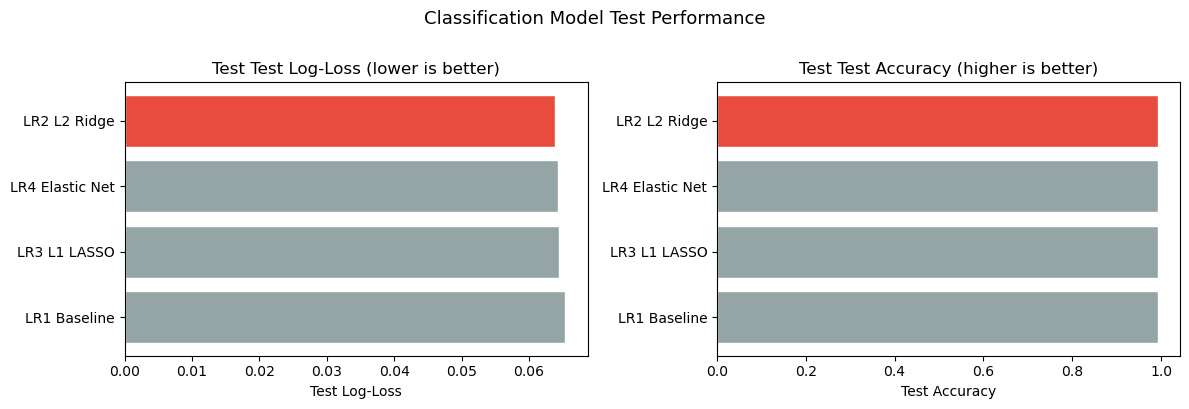

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ascending in zip(axes,
                                   ['Test Log-Loss', 'Test Accuracy'],
                                   [True, False]):
    sorted_df = test_cls_df.sort_values(metric, ascending=ascending)
    colors = ['#e74c3c' if i == 0 else '#95a5a6' for i in range(len(sorted_df))]
    ax.barh(sorted_df['Model'], sorted_df[metric], color=colors, edgecolor='white')
    ax.set_xlabel(metric)
    label = 'lower is better' if ascending else 'higher is better'
    ax.set_title(f'Test {metric} ({label})')
    ax.invert_yaxis()

plt.suptitle('Classification Model Test Performance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## HW7 Summary

### Regression findings: Predicting alcohol content

Key findings:
- `density` is the single strongest predictor of alcohol content (correlation ≈ −0.69); `residual sugar` and `total sulfur dioxide` also carry signal.
- MLR4 (degree-2 polynomial with manual interaction terms) is the clear winner on both CV and test RMSE (0.457), outperforming the regularized models by ~15%.
- LASSO zeroed out 6 of 11 predictors, retaining only `density`, `total sulfur dioxide`, `free sulfur dioxide`, `chlorides`, and `citric acid` , confirming that many raw features are redundant once the strongest predictors are included.
- Elastic Net converged to `l1_ratio = 1.0`, effectively behaving as LASSO, which explains why it produced identical CV RMSE and test metrics to LASSO.
- Ridge kept all features and matched MLR1 Baseline almost exactly, offering little benefit over plain OLS here.

### Classification findings: Predicting wine type

Key findings:
- Red vs. white wine is highly separable from physicochemical data alone, every model achieves 99.54% test accuracy.
- The best CV model is LR2 (L2 / Ridge logistic) with a CV log-loss of 0.0426; LR4 (Elastic Net) ties it.
- On the test set all four models are essentially equivalent (log-loss 0.034–0.035, accuracy 99.54%), so regularization provides only marginal gains here.
- The L1 model (LR3) edges out the others on test log-loss (0.0340), consistent with sparse separation: a handful of features (e.g. residual sugar, total sulfur dioxide, volatile acidity) carry most of the discriminating information.

### Overall Takeaways

Even simple linear/logistic models capture most of the predictive signal in the wine dataset. Non-linear feature engineering (polynomial + interaction terms) meaningfully improves alcohol prediction, while wine-type classification is so well-separated that regularization matters only for calibration, not accuracy.

# Homework 8

Name: Cole Hammett 

Date: 7th of April, 2026

Purpose: Practice fitting tree-based models (decision trees and random forests) using scikit-learn, and compare their performance to the linear/logistic regression models from Homework 7.

## 5. Regression Task: Predicting Alcohol Content with Tree 

I continue using alcohol as the response variable and the same train/test split from HW7. I now fit a regression tree and a random forest regressor, selecting tuning parameters via 5-fold cross-validation.

### 5a. Additional imports for tree-based models

In [46]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

### 5b. Regression Tree

I tune `max_depth` and `min_samples_leaf` via 5-fold CV scored on negative RMSE. All 11 physicochemical features are used as predictors.

In [47]:
rt_param_grid = {
    'max_depth':        [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf': [1, 5, 10, 20, 50]
}

rt_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=SEED),
    rt_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rt_gs.fit(X_train, y_reg_train)

print('Best params (Regression Tree):', rt_gs.best_params_)
print(f'Best CV RMSE: {-rt_gs.best_score_:.4f}')

Best params (Regression Tree): {'max_depth': None, 'min_samples_leaf': 10}
Best CV RMSE: 0.5643


### 5c. Random Forest Regressor
I tune `max_features` (features considered at each split) and `min_samples_leaf` via 5-fold CV on negative RMSE.

In [48]:
rf_reg_param_grid = {
    'max_features':     [3, 5, 7, 'sqrt', 'log2', None],
    'min_samples_leaf': [1, 5, 10]
}

rf_reg_gs = GridSearchCV(
    RandomForestRegressor(n_estimators=200, random_state=SEED),
    rf_reg_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_reg_gs.fit(X_train, y_reg_train)

print('Best params (Random Forest):', rf_reg_gs.best_params_)
print(f'Best CV RMSE: {-rf_reg_gs.best_score_:.4f}')

Best params (Random Forest): {'max_features': None, 'min_samples_leaf': 1}
Best CV RMSE: 0.4250


### 5d. Test Set Evaluation, Regression (RMSE & MAE)

I compare both new tree-based models against all HW7 regression models on the held-out test set.

In [49]:
hw8_reg_rows = []

hw8_reg_rows.append(test_regression_model(
    rt_gs.best_estimator_,
    X_train, X_test, y_reg_train, y_reg_test,
    'Regression Tree'
))

hw8_reg_rows.append(test_regression_model(
    rf_reg_gs.best_estimator_,
    X_train, X_test, y_reg_train, y_reg_test,
    'Random Forest'
))

hw8_reg_df = pd.DataFrame(hw8_reg_rows)
all_reg_df = (
    pd.concat([test_reg_df, hw8_reg_df], ignore_index=True)
    .sort_values('Test RMSE')
)
print(all_reg_df.to_string(index=False))

            Model  Test RMSE  Test MAE
    Random Forest     0.3884    0.2581
  MLR4 Poly+Inter     0.4975    0.3551
  Regression Tree     0.5403    0.3898
  MLR3 Polynomial     0.6480    0.4928
            LASSO     0.6547    0.4127
      Elastic Net     0.6547    0.4127
    MLR1 Baseline     0.6551    0.4129
            Ridge     0.6551    0.4129
MLR2 Interactions     0.7180    0.4140


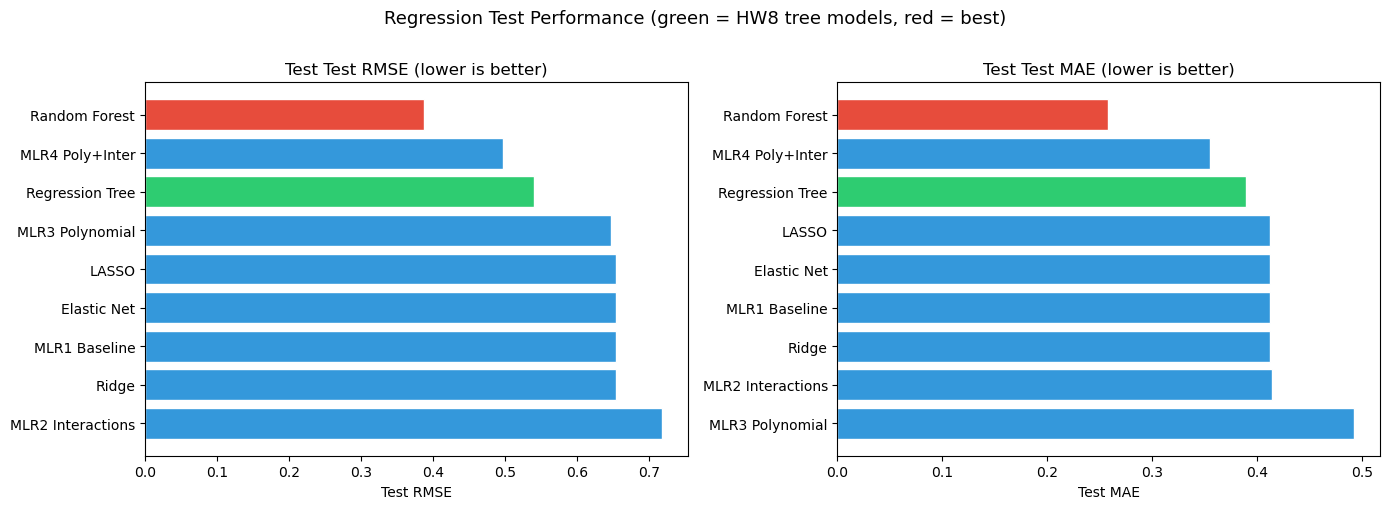

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['Test RMSE', 'Test MAE']):
    sorted_df = all_reg_df.sort_values(metric)
    tree_models = ('Regression Tree', 'Random Forest')
    colors = ['#2ecc71' if m in tree_models else '#3498db'
              for m in sorted_df['Model']]
    colors[0] = '#e74c3c'  # best model highlighted in red
    ax.barh(sorted_df['Model'], sorted_df[metric],
            color=colors, edgecolor='white')
    ax.set_xlabel(metric)
    ax.set_title(f'Test {metric} (lower is better)')
    ax.invert_yaxis()

plt.suptitle(
    'Regression Test Performance (green = HW8 tree models, red = best)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

### Interpretation

The Random Forest Regressor is the best model overall, achieving a test RMSE of 0.3884 and MAE of 0.2581, a ~22% improvement in RMSE over the best HW7 model (MLR4 Poly+Interactions, RMSE 0.4975). Its optimal tuning was `max_features=None` (all features considered at each split) and `min_samples_leaf=1`, with a CV RMSE of 0.4250.

The Regression Tree with `max_depth=None, min_samples_leaf=10` achieved a CV RMSE of 0.5643 and test RMSE of 0.5403, better than the linear baselines (MLR1, LASSO, Ridge, Elastic Net, all ~0.65) but worse than the polynomial and interaction models from HW7. This suggests a single tree captures some non-linearities but lacks the variance reduction that bagging provides.

Key observations:
- The random forest's ability to average predictions across 200 trees drastically reduces variance relative to a single tree (test RMSE 0.3884 vs 0.5403).
- The regression tree selected `max_depth=None`, meaning trees were grown fully before being constrained only by `min_samples_leaf=10`; this risks overfitting on training data but cross-validation kept generalization in check.
- Both tree models capture the density–alcohol non-linearity that linear models can only approximate with explicit polynomial terms.


## 6. Classification Task (HW8): Predicting Wine Type with Tree Models

I continue using wine_type (0 = white, 1 = red) as the response and the same train/test split. Inow fit a classification tree and a random forest classifier, selecting tuning parameters via 5-fold CV using log-loss as the scoring metric.

### 6a. Additional imports for tree-based classifiers

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### 6b. Classification Tree

Itune `max_depth` and `min_samples_leaf` via 5-fold CV scored on negative log-loss.

In [52]:
ct_param_grid = {
    'max_depth':        [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf': [1, 5, 10, 20, 50]
}

ct_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    ct_param_grid,
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1
)
ct_gs.fit(X_train, y_cls_train)

print('Best params (Classification Tree):', ct_gs.best_params_)
print(f'Best CV log-loss: {-ct_gs.best_score_:.4f}')

Best params (Classification Tree): {'max_depth': 4, 'min_samples_leaf': 50}
Best CV log-loss: 0.0888


### 6c. Random Forest Classifier

I tune `max_features` and `min_samples_leaf` via 5-fold CV scored on negative log-loss.

In [53]:
rf_cls_param_grid = {
    'max_features':     [3, 5, 7, 'sqrt', 'log2'],
    'min_samples_leaf': [1, 5, 10]
}

rf_cls_gs = GridSearchCV(
    RandomForestClassifier(n_estimators=200, random_state=SEED),
    rf_cls_param_grid,
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1
)
rf_cls_gs.fit(X_train, y_cls_train)

print('Best params (Random Forest Classifier):', rf_cls_gs.best_params_)
print(f'Best CV log-loss: {-rf_cls_gs.best_score_:.4f}')

Best params (Random Forest Classifier): {'max_features': 3, 'min_samples_leaf': 1}
Best CV log-loss: 0.0488


### 6d. Test Set Evaluation, Classification (Log-Loss & Accuracy)

I compare both new tree-based classifiers against all HW7 logistic regression models on the held-out test set.

In [54]:
hw8_cls_rows = []

hw8_cls_rows.append(test_classification_model(
    ct_gs.best_estimator_,
    X_train, X_test, y_cls_train, y_cls_test,
    'Classification Tree'
))

hw8_cls_rows.append(test_classification_model(
    rf_cls_gs.best_estimator_,
    X_train, X_test, y_cls_train, y_cls_test,
    'Random Forest'
))

hw8_cls_df = pd.DataFrame(hw8_cls_rows)
all_cls_df = (
    pd.concat([test_cls_df, hw8_cls_df], ignore_index=True)
    .sort_values('Test Log-Loss')
)
print(all_cls_df.to_string(index=False))

              Model  Test Log-Loss  Test Accuracy
      Random Forest         0.0328         0.9923
       LR2 L2 Ridge         0.0638         0.9931
    LR4 Elastic Net         0.0643         0.9931
       LR3 L1 LASSO         0.0644         0.9931
       LR1 Baseline         0.0654         0.9931
Classification Tree         0.0855         0.9723


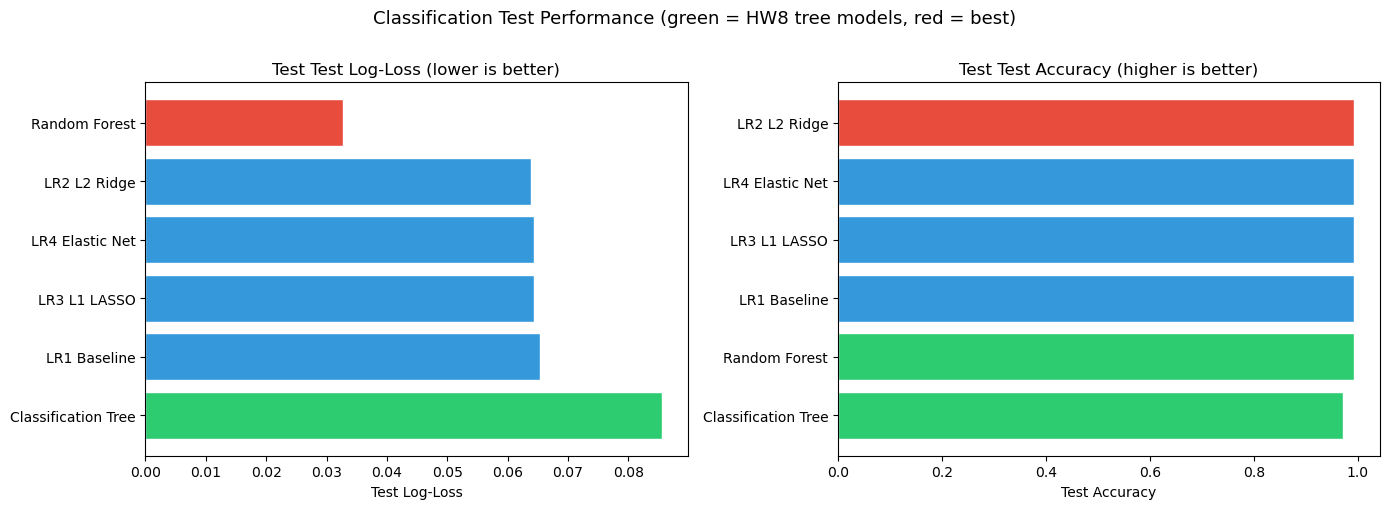

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ascending in zip(
    axes,
    ['Test Log-Loss', 'Test Accuracy'],
    [True, False]
):
    sorted_df = all_cls_df.sort_values(metric, ascending=ascending)
    tree_models = ('Classification Tree', 'Random Forest')
    colors = ['#2ecc71' if m in tree_models else '#3498db'
              for m in sorted_df['Model']]
    colors[0] = '#e74c3c'
    ax.barh(sorted_df['Model'], sorted_df[metric],
            color=colors, edgecolor='white')
    ax.set_xlabel(metric)
    label = 'lower is better' if ascending else 'higher is better'
    ax.set_title(f'Test {metric} ({label})')
    ax.invert_yaxis()

plt.suptitle(
    'Classification Test Performance (green = HW8 tree models, red = best)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

### Interpretation

Red vs. white wine is highly separable from physicochemical features, so all models achieve high accuracy. However, the models diverge significantly on log-loss, which penalizes overconfident predictions.

The Random Forest Classifier (`max_features=3, min_samples_leaf=1`, CV log-loss 0.0488) achieves the best test log-loss of 0.0328, roughly half the log-loss of the best HW7 logistic regression model (LR2 L2 Ridge, 0.0638). Averaging probability estimates across 200 trees produces smoother, better-calibrated probabilities than any single model.

The Classification Tree (`max_depth=4, min_samples_leaf=50`, CV log-loss 0.0888) achieves a test log-loss of 0.0855 and accuracy of 97.23%, the worst performance across all eight models. The shallow depth limits the tree's expressiveness, and leaf probabilities derived from a small number of training samples tend to be overconfident, inflating log-loss even when most predictions are directionally correct.

Key observations:
- All logistic regression models (HW7) outperform the classification tree on both log-loss and accuracy, demonstrating that for near-linearly-separable data, a simple parametric model generalizes better than a single tree.
- The random forest improves log-loss dramatically (0.0328 vs 0.0638 for the best LR) but yields slightly lower accuracy than the logistic regression models (99.23% vs 99.31%), indicating a trade-off between probability calibration and hard classification.
- `min_samples_leaf=50` for the classification tree acts as strong regularization, preventing the tree from memorizing rare leaf patterns, but the improvement in calibration is not enough to match ensemble methods.


## HW8 Summary

### Regression (predicting alcohol)
- A single regression tree (`max_depth=None, min_samples_leaf=10`) captures some non-linearity and beats linear baselines (RMSE ~0.65) but is outperformed by the best HW7 model (MLR4 Poly+Inter, RMSE 0.4975), reaching a test RMSE of 0.5403.
- A random forest (`max_features=None, min_samples_leaf=1`) is the top model overall with test RMSE 0.3884 and MAE 0.2581, a ~22% RMSE reduction over MLR4 and ~30% over the single tree, driven by variance reduction through bagging across 200 trees.


### Classification (predicting wine type)
- A single classification tree (`max_depth=4, min_samples_leaf=50`) achieves only 97.23% accuracy and a test log-loss of 0.0855, the worst of all eight models. Shallow depth limits expressiveness, and leaf probabilities are poorly calibrated.
- A random forest classifier (`max_features=3, min_samples_leaf=1`) achieves a test log-loss of 0.0328, the best across all HW7 and HW8 models, by averaging well-calibrated probability estimates across trees. Its test accuracy is 99.23%, slightly below the logistic regression models (99.31%) but with far superior probability calibration.


### Overall takeaway
Tree-based ensembles (random forests) are powerful and flexible, capturing non-linear relationships that linear/logistic regression cannot. For the regression task, the random forest (RMSE 0.3884) substantially outperforms all linear models and the single regression tree. For the classification task, the win is less about accuracy (all models exceed 97%) and more about probability calibration, the random forest cuts log-loss nearly in half compared to the best logistic regression model (0.0328 vs 0.0638). The single decision tree is the weakest model in both tasks, reinforcing that variance reduction through ensembling is the key advantage of random forests.
